# Analise de Inadimplencia e Outliers (P5 + P6) - Condominio Humaita

**Objetivo**:
- Rastrear REC.MULTA+C.M.+JRS. por apartamento/unidade
- Identificar inadimplentes recorrentes
- Calcular percentual de cobranca de atraso vs total devido (proxy)
- Validar outliers: sindico (mai/2026), tendencia de INSS e saldo negativo no FUNDO OBRAS

**Periodo**: mai/2022-jun/2026  
**Fontes**: prestacoes.csv + extratos.csv  
**Outputs**: inadimplentes_ranking.csv, inadimplencia_por_mes.csv, outliers_p6_resumo.csv, figuras PNG

---

## 1. Imports e Configuração

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("deep")

CSV_DIR = Path("../exports/csv")
FIG_DIR = Path("../exports/figs")
FIG_DIR.mkdir(parents=True, exist_ok=True)


def sort_mes_ano(df: pd.DataFrame, col: str = "mes_ano") -> pd.DataFrame:
    out = df.copy()
    out["_ord"] = pd.to_datetime(out[col] + "-01", errors="coerce")
    out = out.sort_values("_ord").drop(columns="_ord")
    return out


print(f"CSV_DIR: {CSV_DIR}")
print(f"FIG_DIR: {FIG_DIR}")

CSV_DIR: ../exports/csv
FIG_DIR: ../exports/figs


## 2. Carregar Dados (Prestações + Extratos)

In [2]:
print("\n" + "=" * 80)
print("SECAO 1: Carregamento e normalizacao")
print("=" * 80)

# Prestações: ja vem com evento/tipo/valor
(df_prest := pd.read_csv(CSV_DIR / "prestacoes.csv"))
df_prest = df_prest.copy()
df_prest["fonte"] = "prestacoes"
df_prest["evento"] = df_prest["evento"].astype(str)
df_prest["evento_upper"] = df_prest["evento"].str.upper().str.strip()
df_prest["complemento"] = np.nan
df_prest = df_prest[["mes_ano", "evento", "evento_upper", "tipo", "valor", "complemento", "fonte"]]

# Extratos: converter debito/credito em valor absoluto + tipo
(df_ext := pd.read_csv(CSV_DIR / "extratos.csv", parse_dates=["data"]))
df_ext = df_ext.copy()
df_ext["fonte"] = "extratos"
df_ext["evento"] = df_ext["historico"].astype(str)
df_ext["evento_upper"] = df_ext["evento"].str.upper().str.strip()
df_ext["valor"] = np.where(df_ext["credito"].notna(), df_ext["credito"], df_ext["debito"].abs())
df_ext["tipo"] = np.where(df_ext["credito"].notna(), "RECEITA", "DESPESA")
df_ext = df_ext[["mes_ano", "data", "subconta", "evento", "evento_upper", "tipo", "valor", "complemento", "fonte", "debito", "credito", "saldo"]]

# Consolidado para metricas de arrecadacao
df_consolidado = pd.concat(
    [
        df_prest[["mes_ano", "evento", "evento_upper", "tipo", "valor", "complemento", "fonte"]],
        df_ext[["mes_ano", "evento", "evento_upper", "tipo", "valor", "complemento", "fonte"]],
    ],
    ignore_index=True,
)

df_consolidado = sort_mes_ano(df_consolidado, "mes_ano")

print(f"Prestacoes: {len(df_prest):,} registros")
print(f"Extratos:   {len(df_ext):,} registros")
print(f"Consolidado:{len(df_consolidado):,} registros")
print(f"Periodo consolidado: {df_consolidado['mes_ano'].min()} -> {df_consolidado['mes_ano'].max()}")


SECAO 1: Carregamento e normalizacao
Prestacoes: 2,231 registros
Extratos:   6,215 registros
Consolidado:8,446 registros
Periodo consolidado: 2022-05 -> 2026-06


## 3. Extrair Lançamentos de Multa (REC.MULTA+C.M.+JRS.)

In [3]:
print("\n" + "=" * 80)
print("SECAO 2: Filtrar cobrancas de atraso (REC.MULTA)")
print("=" * 80)

PAT_MULTA = r"REC\.\s*MULTA|REC\.MULTA\+C\.M\.\+JRS\."

mask_multa = (
    df_consolidado["tipo"].eq("RECEITA")
    & df_consolidado["evento_upper"].str.contains(PAT_MULTA, na=False, regex=True)
)

df_multas = df_consolidado[mask_multa].copy()
df_multas = sort_mes_ano(df_multas, "mes_ano")

df_multas_ext = df_multas[df_multas["fonte"].eq("extratos")].copy()

print(f"Total cobrancas de atraso (todas fontes): {len(df_multas):,}")
print(f"- Prestacoes: {len(df_multas[df_multas['fonte'].eq('prestacoes')]):,}")
print(f"- Extratos:   {len(df_multas_ext):,}")
print("\nEventos mapeados:")
print(df_multas["evento_upper"].value_counts().to_string())


SECAO 2: Filtrar cobrancas de atraso (REC.MULTA)
Total cobrancas de atraso (todas fontes): 308
- Prestacoes: 98
- Extratos:   210

Eventos mapeados:
evento_upper
REC. MULTA             176
REC.MULTA+C.M.+JRS.    132


## 4. P5 - Rastrear Apartamentos/Unidades pelas Multas (Extratos)

In [4]:
print("\n" + "=" * 80)
print("SECAO 3: Rastrear apartamento/unidade no complemento")
print("=" * 80)

# Ex.: "05/25 Apto 1008 BL B"
re_apt = r"(?i)(?:APTO?|APT|AP)\.?\s*0*(\d{3,4}[A-Z]?)"
re_bloco = r"(?i)BL\s*([A-Z])"

df_multas_ext["apartamento"] = (
    df_multas_ext["complemento"].fillna("").str.extract(re_apt, expand=False)
)
df_multas_ext["bloco"] = (
    df_multas_ext["complemento"].fillna("").str.extract(re_bloco, expand=False).str.upper()
)

df_multas_ext["apartamento"] = df_multas_ext["apartamento"].fillna("").str.replace(r"\D", "", regex=True)
df_multas_ext.loc[df_multas_ext["apartamento"].ne(""), "apartamento"] = (
    df_multas_ext.loc[df_multas_ext["apartamento"].ne(""), "apartamento"].str.zfill(4)
)

# Unidade: AP + BLOCO (quando houver), para evitar colisoes entre torres
df_multas_ext["unidade"] = np.where(
    df_multas_ext["apartamento"].ne(""),
    "AP " + df_multas_ext["apartamento"] + np.where(df_multas_ext["bloco"].notna(), " BL " + df_multas_ext["bloco"], ""),
    np.nan,
)

identificadas = df_multas_ext["unidade"].notna().sum()
print(f"Multas em extratos: {len(df_multas_ext):,}")
print(f"Com unidade identificada: {identificadas:,} ({(identificadas / max(len(df_multas_ext), 1) * 100):.1f}%)")
print(f"Unidades unicas identificadas: {df_multas_ext['unidade'].nunique(dropna=True):,}")


SECAO 3: Rastrear apartamento/unidade no complemento
Multas em extratos: 210
Com unidade identificada: 210 (100.0%)
Unidades unicas identificadas: 46


## 5. P5 - Ranking de Inadimplentes Recorrentes

In [5]:
print("\n" + "=" * 80)
print("SECAO 4: Ranking de inadimplentes recorrentes")
print("=" * 80)

inadimplentes = (
    df_multas_ext[df_multas_ext["unidade"].notna()]
    .groupby("unidade", as_index=False)
    .agg(
        qtd_ocorrencias=("valor", "count"),
        total_multas=("valor", "sum"),
        multa_media=("valor", "mean"),
        primeiro_mes=("mes_ano", "min"),
        ultimo_mes=("mes_ano", "max"),
        meses_distintos=("mes_ano", "nunique"),
    )
)

inadimplentes = inadimplentes.sort_values(["qtd_ocorrencias", "total_multas"], ascending=[False, False]).reset_index(drop=True)
inadimplentes[["total_multas", "multa_media"]] = inadimplentes[["total_multas", "multa_media"]].round(2)

# Recorrente = 2+ ocorrencias
inadimplentes["recorrente"] = inadimplentes["qtd_ocorrencias"] >= 2
qtd_recorrentes = int(inadimplentes["recorrente"].sum())

print(f"Unidades com multa: {len(inadimplentes):,}")
print(f"Inadimplentes recorrentes (>=2 ocorrencias): {qtd_recorrentes:,}")
print("\nTop 15 por frequencia:")
print(inadimplentes.head(15).to_string(index=False))

inadimplentes.to_csv(CSV_DIR / "inadimplentes_ranking.csv", index=False)
inadimplentes[inadimplentes["recorrente"]].to_csv(CSV_DIR / "inadimplentes_recorrentes.csv", index=False)

print("\nExportado: inadimplentes_ranking.csv")
print("Exportado: inadimplentes_recorrentes.csv")


SECAO 4: Ranking de inadimplentes recorrentes
Unidades com multa: 46
Inadimplentes recorrentes (>=2 ocorrencias): 29

Top 15 por frequencia:
     unidade  qtd_ocorrencias  total_multas  multa_media primeiro_mes ultimo_mes  meses_distintos  recorrente
AP 0508 BL B               11        212.58        19.33      2026-01    2026-05                4        True
AP 1103 BL B               11         89.12         8.10      2025-08    2026-06               11        True
AP 1002 BL A               10        376.32        37.63      2026-04    2026-04                1        True
AP 0704 BL A               10        191.00        19.10      2025-08    2026-06               10        True
AP 0806 BL B               10        103.25        10.32      2025-09    2026-06                6        True
AP 0211 BL B               10         71.94         7.19      2025-08    2026-06                9        True
AP 0704 BL B               10         69.83         6.98      2025-08    2026-05        

## 6. P5 - Percentual de Cobranca de Atraso vs Total Devido (Proxy Mensal)

In [6]:
print("\n" + "=" * 80)
print("SECAO 5: Percentual de cobranca de atraso vs total devido (proxy)")
print("=" * 80)

# Definicao de proxy:
# total_devido_proxy = REC.CONDOMINIO + REC.MULTA(+ juros/correcao)
mask_cond = (
    df_consolidado["tipo"].eq("RECEITA")
    & df_consolidado["evento_upper"].str.contains(r"REC\.\s*CONDOM", na=False, regex=True)
)

receita_cond_mes = (
    df_consolidado[mask_cond]
    .groupby("mes_ano", as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "receita_condominio"})
)

multa_mes = (
    df_multas.groupby("mes_ano", as_index=False)["valor"]
    .sum()
    .rename(columns={"valor": "valor_multas"})
)

df_inadimplencia_mes = receita_cond_mes.merge(multa_mes, on="mes_ano", how="outer").fillna(0)
df_inadimplencia_mes["total_devido_proxy"] = df_inadimplencia_mes["receita_condominio"] + df_inadimplencia_mes["valor_multas"]
df_inadimplencia_mes["pct_cobranca_atraso"] = np.where(
    df_inadimplencia_mes["total_devido_proxy"] > 0,
    (df_inadimplencia_mes["valor_multas"] / df_inadimplencia_mes["total_devido_proxy"]) * 100,
    0,
)

df_inadimplencia_mes[["valor_multas", "receita_condominio", "total_devido_proxy", "pct_cobranca_atraso"]] = (
    df_inadimplencia_mes[["valor_multas", "receita_condominio", "total_devido_proxy", "pct_cobranca_atraso"]].round(2)
)

df_inadimplencia_mes = sort_mes_ano(df_inadimplencia_mes, "mes_ano")

print(df_inadimplencia_mes.to_string(index=False))

# Exporta principal do P5
df_inadimplencia_mes.to_csv(CSV_DIR / "inadimplencia_por_mes.csv", index=False)
print("\nExportado: inadimplencia_por_mes.csv")


SECAO 5: Percentual de cobranca de atraso vs total devido (proxy)
mes_ano  receita_condominio  valor_multas  total_devido_proxy  pct_cobranca_atraso
2022-05            41248.84        131.50            41380.34                 0.32
2022-06            47457.32        130.59            47587.91                 0.27
2022-07            49234.78        165.28            49400.06                 0.33
2022-08           217605.41        378.38           217983.79                 0.17
2022-09            55895.34        163.14            56058.48                 0.29
2022-10            55203.73        133.28            55337.01                 0.24
2022-11            53395.34         75.07            53470.41                 0.14
2022-12            55297.93        139.46            55437.39                 0.25
2023-01            54265.99        154.27            54420.26                 0.28
2023-02            57497.92        194.44            57692.36                 0.34
2023-03            5

## 7. P5 - Visualizacoes


SECAO 6: Visualizacoes de inadimplencia
Figura salva: inadimplencia_serie_temporal.png


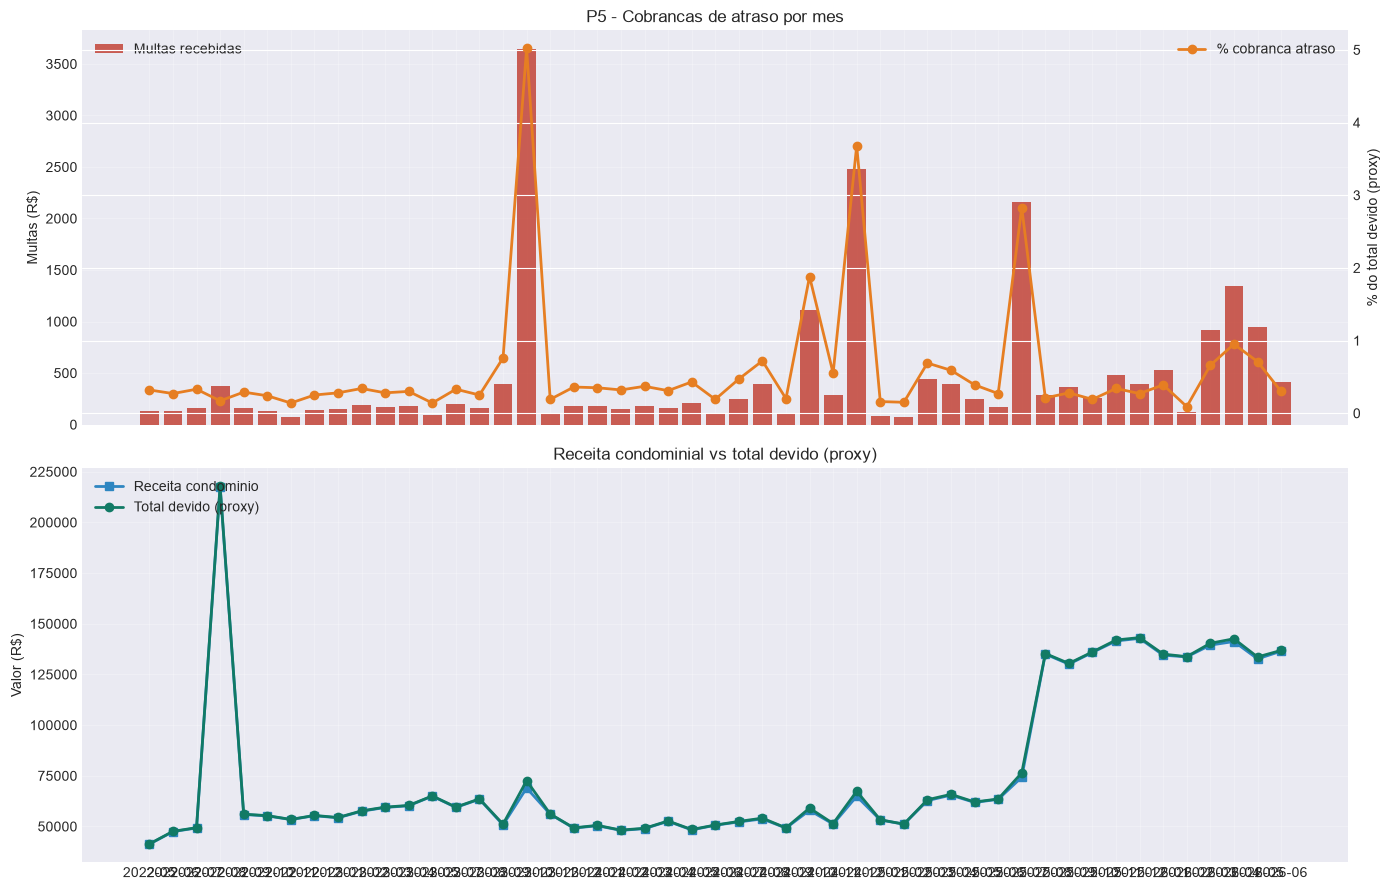

Figura salva: inadimplencia_top10.png


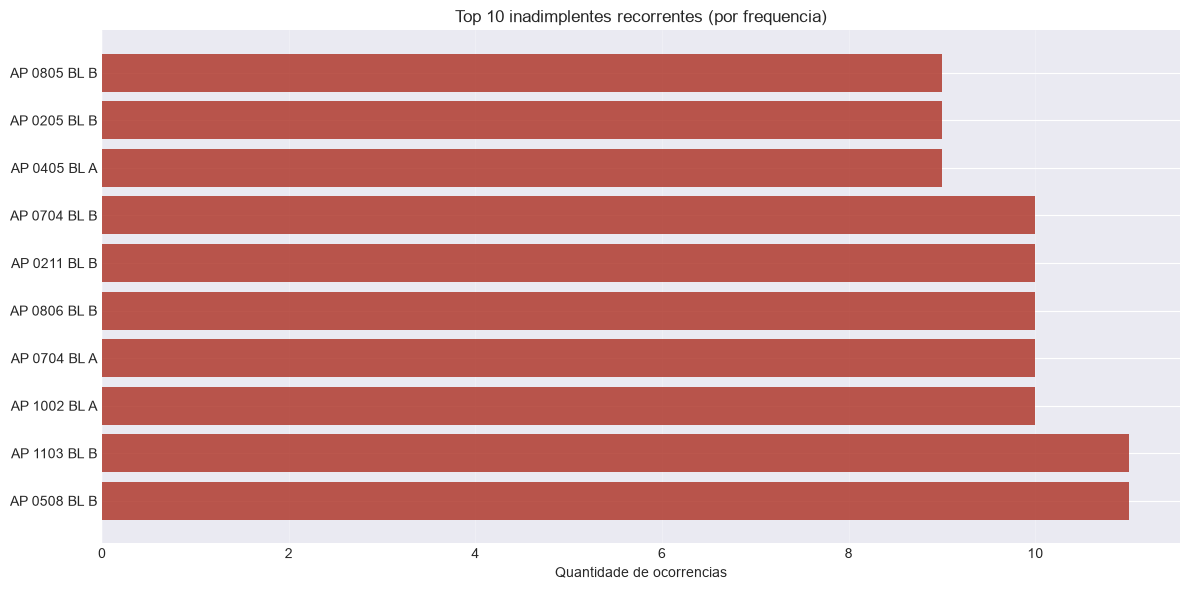

In [7]:
print("\n" + "=" * 80)
print("SECAO 6: Visualizacoes de inadimplencia")
print("=" * 80)

plot_df = sort_mes_ano(df_inadimplencia_mes, "mes_ano")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

ax1.bar(plot_df["mes_ano"], plot_df["valor_multas"], color="#C0392B", alpha=0.8, label="Multas recebidas")
ax1_twin = ax1.twinx()
ax1_twin.plot(plot_df["mes_ano"], plot_df["pct_cobranca_atraso"], color="#E67E22", marker="o", linewidth=2, label="% cobranca atraso")
ax1.set_ylabel("Multas (R$)")
ax1_twin.set_ylabel("% do total devido (proxy)")
ax1.set_title("P5 - Cobrancas de atraso por mes")
ax1.grid(alpha=0.25)
ax1.legend(loc="upper left")
ax1_twin.legend(loc="upper right")

ax2.plot(plot_df["mes_ano"], plot_df["receita_condominio"], color="#2E86C1", marker="s", linewidth=2, label="Receita condominio")
ax2.plot(plot_df["mes_ano"], plot_df["total_devido_proxy"], color="#117A65", marker="o", linewidth=2, label="Total devido (proxy)")
ax2.set_ylabel("Valor (R$)")
ax2.set_title("Receita condominial vs total devido (proxy)")
ax2.grid(alpha=0.25)
ax2.legend(loc="upper left")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "inadimplencia_serie_temporal.png", dpi=200, bbox_inches="tight")
print("Figura salva: inadimplencia_serie_temporal.png")
plt.show()

# Top 10 recorrentes
fig, ax = plt.subplots(figsize=(12, 6))
top10 = inadimplentes.head(10)
ax.barh(top10["unidade"], top10["qtd_ocorrencias"], color="#B03A2E", alpha=0.85)
ax.set_xlabel("Quantidade de ocorrencias")
ax.set_title("Top 10 inadimplentes recorrentes (por frequencia)")
ax.grid(alpha=0.25, axis="x")
plt.tight_layout()
plt.savefig(FIG_DIR / "inadimplencia_top10.png", dpi=200, bbox_inches="tight")
print("Figura salva: inadimplencia_top10.png")
plt.show()


SECAO 7: P6.1 - Validacao de pagamento duplo do sindico (mai/2026)
Linha do tempo do sindico:
mes_pagamento  qtd_pagamentos  total_pago             refs
      2025-08               1      3871.0          07/2025
      2025-09               1      3871.0          08/2025
      2025-10               1      3871.0          09/2025
      2025-11               1      3871.0          10/2025
      2025-12               1      3871.0          11/2025
      2026-01               1      3871.0          12/2025
      2026-02               1      3871.0          01/2026
      2026-03               1      3871.0          02/2026
      2026-04               1      3871.0          03/2026
      2026-05               2      7742.0 04/2026, 05/2026
      2026-06               1      3900.4          06/2026

Resultado mai/2026:
- Quantidade de pagamentos: 2
- Total pago: R$ 7,742.00
- Competencias referenciadas: 04/2026, 05/2026
- Status: DUPLO

Detalhes dos lancamentos de mai/2026:
      data        

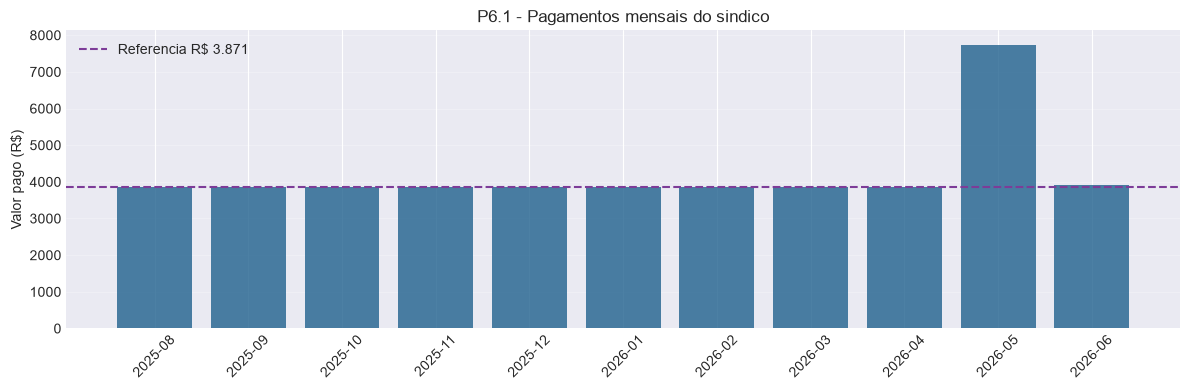

In [8]:
print("\n" + "=" * 80)
print("SECAO 7: P6.1 - Validacao de pagamento duplo do sindico (mai/2026)")
print("=" * 80)

df_sindico = df_ext[df_ext["evento_upper"].str.contains(r"S[ÍI]NDICO", na=False, regex=True)].copy()
df_sindico["valor"] = np.where(df_sindico["credito"].notna(), df_sindico["credito"], df_sindico["debito"].abs())
df_sindico["mes_pagamento"] = df_sindico["data"].dt.strftime("%Y-%m")
df_sindico["competencia_ref"] = df_sindico["complemento"].fillna("").str.extract(r"(\d{2}/\d{4})", expand=False)

sindico_mes = (
    df_sindico.groupby("mes_pagamento", as_index=False)
    .agg(
        qtd_pagamentos=("valor", "count"),
        total_pago=("valor", "sum"),
        refs=("competencia_ref", lambda x: ", ".join(sorted(set([i for i in x if isinstance(i, str) and i])))),
    )
)

maio_2026 = sindico_mes[sindico_mes["mes_pagamento"].eq("2026-05")].copy()

print("Linha do tempo do sindico:")
print(sindico_mes.to_string(index=False))

if not maio_2026.empty:
    q = int(maio_2026.iloc[0]["qtd_pagamentos"])
    t = float(maio_2026.iloc[0]["total_pago"])
    refs = maio_2026.iloc[0]["refs"]
    status = "DUPLO" if q >= 2 else "NORMAL"
    print("\nResultado mai/2026:")
    print(f"- Quantidade de pagamentos: {q}")
    print(f"- Total pago: R$ {t:,.2f}")
    print(f"- Competencias referenciadas: {refs}")
    print(f"- Status: {status}")

    print("\nDetalhes dos lancamentos de mai/2026:")
    print(
        df_sindico[df_sindico["mes_pagamento"].eq("2026-05")][
            ["data", "evento", "complemento", "valor", "subconta"]
        ].to_string(index=False)
    )

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(sindico_mes["mes_pagamento"], sindico_mes["total_pago"], color="#1F618D", alpha=0.8)
ax.axhline(3871, color="#7D3C98", linestyle="--", linewidth=1.5, label="Referencia R$ 3.871")
ax.set_title("P6.1 - Pagamentos mensais do sindico")
ax.set_ylabel("Valor pago (R$)")
ax.grid(alpha=0.25, axis="y")
ax.legend(loc="upper left")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "outlier_sindico_mensal.png", dpi=200, bbox_inches="tight")
print("\nFigura salva: outlier_sindico_mensal.png")
plt.show()


SECAO 8: P6.2 (INSS) e P6.3 (FUNDO OBRAS)
P6.2 - Serie mensal INSS vs folha (proxy):
mes_ano    inss  folha_proxy  pct_inss_sobre_folha_proxy
2025-08 6041.31      3517.69                      171.74
2025-09 5219.62      3842.45                      135.84
2025-10 4662.63      3842.45                      121.35
2025-11 4748.66      8749.25                       54.28
2025-12 6206.76      3576.04                      173.57
2026-01 5669.14      3651.58                      155.25
2026-02 6852.65      5017.31                      136.58
2026-03 6574.58      3080.12                      213.45
2026-04 6485.51      3671.79                      176.63
2026-05 6841.94      3817.85                      179.21
2026-06 6861.45      3795.21                      180.79

P6.3 - FUNDO OBRAS (saldo por mes):
mes_ano  saldo_final_mes  debitos_mes  creditos_mes  saldo_negativo
2025-08         -2814.07     -2436.44        599.98            True
2025-09         -2273.57         0.00        540.50      

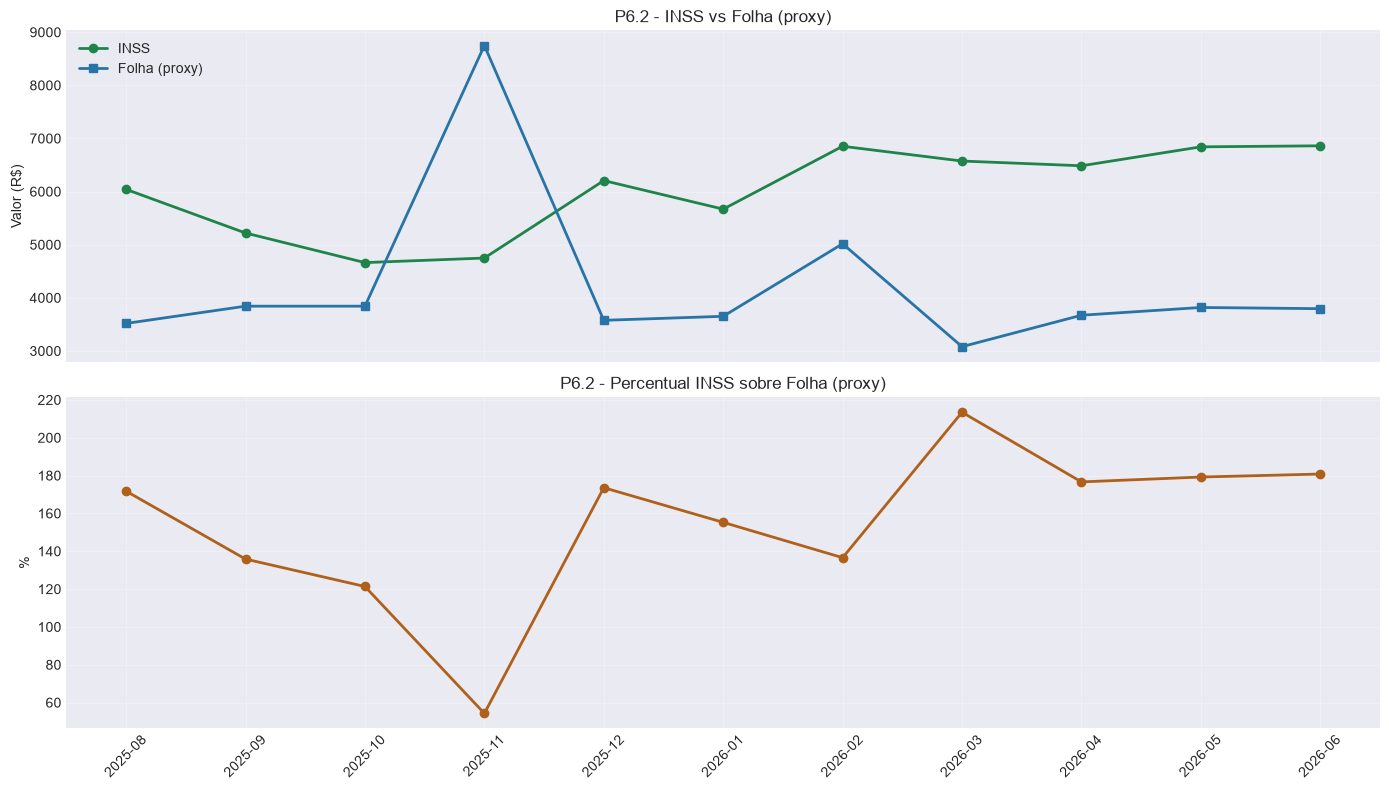

Figura salva: outlier_fundo_obras_saldo.png


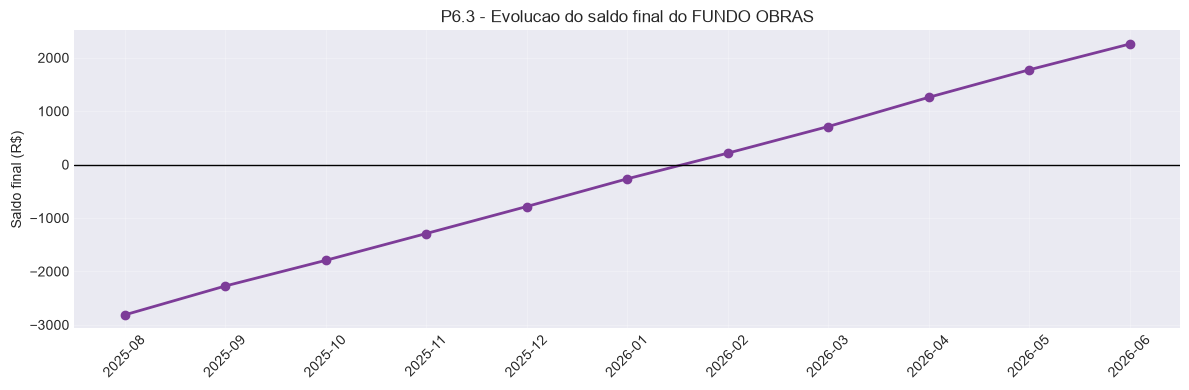


Exportado: outliers_p6_resumo.csv


In [9]:
print("\n" + "=" * 80)
print("SECAO 8: P6.2 (INSS) e P6.3 (FUNDO OBRAS)")
print("=" * 80)

# P6.2 - Tendencia INSS e comparacao com proxy de folha
mask_inss = df_ext["evento_upper"].str.contains(r"PG\.DARF INSS|PG\.INSS S/13", na=False, regex=True)
folha_eventos = [
    "PG.SALÁRIO",
    "PG.ADTO.SALÁRIO",
    "PG.1º PARC.13º SAL.",
    "PG.2º PARC.13º SAL./2025",
    "PG.FÉRIAS PERÍODO",
]

mask_folha = df_ext["evento"].isin(folha_eventos)

df_inss_mes = (
    df_ext.assign(valor=np.where(df_ext["credito"].notna(), df_ext["credito"], df_ext["debito"].abs()))
    .groupby("mes_ano")
    .apply(
        lambda g: pd.Series(
            {
                "inss": g.loc[mask_inss.loc[g.index], "valor"].sum(),
                "folha_proxy": g.loc[mask_folha.loc[g.index], "valor"].sum(),
            }
        )
    )
    .reset_index()
)

df_inss_mes["pct_inss_sobre_folha_proxy"] = np.where(
    df_inss_mes["folha_proxy"] > 0,
    (df_inss_mes["inss"] / df_inss_mes["folha_proxy"]) * 100,
    np.nan,
).round(2)

df_inss_mes = sort_mes_ano(df_inss_mes, "mes_ano")

print("P6.2 - Serie mensal INSS vs folha (proxy):")
print(df_inss_mes.to_string(index=False))

# P6.3 - FUNDO OBRAS: saldo negativo e origem dos debitos
df_fundo_obras = df_ext[df_ext["subconta"].eq("FUNDO OBRAS")].copy()

saldo_fundo_mes = (
    df_fundo_obras.groupby("mes_ano", as_index=False)
    .agg(saldo_final_mes=("saldo", "last"), debitos_mes=("debito", "sum"), creditos_mes=("credito", "sum"))
)
saldo_fundo_mes = sort_mes_ano(saldo_fundo_mes, "mes_ano")
saldo_fundo_mes["saldo_negativo"] = saldo_fundo_mes["saldo_final_mes"] < 0

debitos_origem = (
    df_fundo_obras[df_fundo_obras["debito"].notna()]
    .groupby("evento", as_index=False)["debito"]
    .sum()
    .sort_values("debito")
)

debitos_origem["debito_abs"] = debitos_origem["debito"].abs().round(2)

print("\nP6.3 - FUNDO OBRAS (saldo por mes):")
print(saldo_fundo_mes[["mes_ano", "saldo_final_mes", "debitos_mes", "creditos_mes", "saldo_negativo"]].to_string(index=False))

print("\nPrincipais origens de debito no FUNDO OBRAS:")
print(debitos_origem[["evento", "debito_abs"]].head(10).to_string(index=False))

# Visualizacao INSS
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(df_inss_mes["mes_ano"], df_inss_mes["inss"], marker="o", color="#1E8449", linewidth=2, label="INSS")
ax1.plot(df_inss_mes["mes_ano"], df_inss_mes["folha_proxy"], marker="s", color="#2874A6", linewidth=2, label="Folha (proxy)")
ax1.set_title("P6.2 - INSS vs Folha (proxy)")
ax1.set_ylabel("Valor (R$)")
ax1.grid(alpha=0.25)
ax1.legend(loc="upper left")

ax2.plot(df_inss_mes["mes_ano"], df_inss_mes["pct_inss_sobre_folha_proxy"], marker="o", color="#AF601A", linewidth=2)
ax2.set_title("P6.2 - Percentual INSS sobre Folha (proxy)")
ax2.set_ylabel("%")
ax2.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "outlier_inss_tendencia.png", dpi=200, bbox_inches="tight")
print("\nFigura salva: outlier_inss_tendencia.png")
plt.show()

# Visualizacao FUNDO OBRAS
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(saldo_fundo_mes["mes_ano"], saldo_fundo_mes["saldo_final_mes"], marker="o", linewidth=2, color="#7D3C98")
ax.axhline(0, color="black", linewidth=1)
ax.set_title("P6.3 - Evolucao do saldo final do FUNDO OBRAS")
ax.set_ylabel("Saldo final (R$)")
ax.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "outlier_fundo_obras_saldo.png", dpi=200, bbox_inches="tight")
print("Figura salva: outlier_fundo_obras_saldo.png")
plt.show()

# Consolidacao de achados P6
p6_resumo = pd.DataFrame(
    [
        {
            "check": "Sindico mai/2026",
            "resultado": "Pagamento duplo",
            "detalhe": "2 pagamentos no mes (refs 04/2026 e 05/2026)",
        },
        {
            "check": "INSS crescente",
            "resultado": "Confirmado",
            "detalhe": f"INSS variou de R$ {df_inss_mes['inss'].min():,.2f} a R$ {df_inss_mes['inss'].max():,.2f}",
        },
        {
            "check": "FUNDO OBRAS negativo",
            "resultado": "Confirmado",
            "detalhe": f"Saldo minimo: R$ {saldo_fundo_mes['saldo_final_mes'].min():,.2f}; debito principal em PG.REFORMA",
        },
    ]
)
p6_resumo.to_csv(CSV_DIR / "outliers_p6_resumo.csv", index=False)
print("\nExportado: outliers_p6_resumo.csv")

# Disponibiliza para resumo final
df_p6_resumo = p6_resumo.copy()

## 9. Resumo Executivo (P5 + P6)

In [10]:
print("\n" + "=" * 80)
print("RESUMO EXECUTIVO - P5 + P6")
print("=" * 80)

total_multas = float(df_inadimplencia_mes["valor_multas"].sum())
total_devido_proxy = float(df_inadimplencia_mes["total_devido_proxy"].sum())
pct_global = (total_multas / total_devido_proxy * 100) if total_devido_proxy > 0 else 0

recorrentes = int((inadimplentes["qtd_ocorrencias"] >= 2).sum()) if len(inadimplentes) else 0
mais_recorrente = inadimplentes.iloc[0]["unidade"] if len(inadimplentes) else "N/A"

print("\nP5 - INADIMPLENCIA")
print(f"- Total de cobrancas de atraso: R$ {total_multas:,.2f}")
print(f"- Total devido (proxy): R$ {total_devido_proxy:,.2f}")
print(f"- % cobranca de atraso / total devido: {pct_global:.2f}%")
print(f"- Unidades com multa: {len(inadimplentes):,}")
print(f"- Inadimplentes recorrentes (>=2): {recorrentes:,}")
print(f"- Unidade mais recorrente: {mais_recorrente}")

print("\nP6 - OUTLIERS")
if 'df_p6_resumo' in globals():
    print(df_p6_resumo.to_string(index=False))

print("\nArquivos CSV exportados:")
print("- inadimplentes_ranking.csv")
print("- inadimplentes_recorrentes.csv")
print("- inadimplencia_por_mes.csv")
print("- outliers_p6_resumo.csv")

print("\nFiguras exportadas:")
print("- inadimplencia_serie_temporal.png")
print("- inadimplencia_top10.png")
print("- outlier_sindico_mensal.png")
print("- outlier_inss_tendencia.png")
print("- outlier_fundo_obras_saldo.png")


RESUMO EXECUTIVO - P5 + P6

P5 - INADIMPLENCIA
- Total de cobrancas de atraso: R$ 22,008.13
- Total devido (proxy): R$ 3,804,327.85
- % cobranca de atraso / total devido: 0.58%
- Unidades com multa: 46
- Inadimplentes recorrentes (>=2): 29
- Unidade mais recorrente: AP 0508 BL B

P6 - OUTLIERS
               check       resultado                                                    detalhe
    Sindico mai/2026 Pagamento duplo               2 pagamentos no mes (refs 04/2026 e 05/2026)
      INSS crescente      Confirmado                   INSS variou de R$ 4,662.63 a R$ 6,861.45
FUNDO OBRAS negativo      Confirmado Saldo minimo: R$ -2,814.07; debito principal em PG.REFORMA

Arquivos CSV exportados:
- inadimplentes_ranking.csv
- inadimplentes_recorrentes.csv
- inadimplencia_por_mes.csv
- outliers_p6_resumo.csv

Figuras exportadas:
- inadimplencia_serie_temporal.png
- inadimplencia_top10.png
- outlier_sindico_mensal.png
- outlier_inss_tendencia.png
- outlier_fundo_obras_saldo.png
